# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Hafidz Ibnu Ibrahim Ritonga
- **Email:** hafizibnu9@gmail.com
- **ID Dicoding:** ibnu_hafidz

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa saja yang menghasilkan total pendapatan/revenue tertinggi dan jumlah pesanan terbanyak sepanjang tahun 2017?
- **Pertanyaan 2:** Berapa proporsi penggunaan masing-masing tipe pembayaran dan rata-rata nilai transaksi per pesanan sepanjang tahun 2018?

## Import Semua Packages/Library yang Digunakan

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [49]:
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
product_category_name_df = pd.read_csv("product_category_name_translation.csv")
order_payments_df = pd.read_csv("order_payments_dataset.csv")

**Insight:** (Opsional)
- Dataset yang digunakan sudah bisa menjawab pertanyaan bisnis dengan mengaggregasi mereka sesuai kebutuhan analisa.
- product_category_name_translation.csv penting untuk menyeragamkan nama barang ke bahasa Inggris untuk memudahkan analisa.

### Assessing Data

#### Identifying ... problem

In [36]:
orders_df.info()
orders_df.isna().sum()
orders_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [37]:
order_items_df.info()
order_items_df.isna().sum()
order_items_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [38]:
products_df.info()
products_df.isna().sum()
products_df.describe()
products_df['product_category_name'].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


73

In [39]:
product_category_name_df.info()
product_category_name_df.isna().sum()
product_category_name_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [40]:
order_payments_df.info()
order_payments_df.isna().sum()
order_payments_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Steps to Take:**
- kolom order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date order_estimated_delivery_date akan diubah menjadi format datetime
- kolom order_status pada orders_df akan diubah jadi category
- Mengubah kolom shipping_limit_date pada order_items ke format datetime
- mengatasi data null di products_df
- product_category_name_english untuk products_df, gunakan merge left dan fallback dengan nama produk asli atau 'unknown'


**Insight:** (Opsional)
- Terdapat null pada order_delivered_carrier_date,order_delivered_customer_date, dan order_approved_at di orders_df
- Jumlah order_items lebih banyak dari orders_id, perlu agregasi untuk penyatuan kedua dataframe
- Terdapat 610 data null pada category_name, name_lenght, description_lenght, dan photos_qty
- Terdapat missing value pada products_category_name_english yang tidak mencakup semua products_category_name yang ada di products_df

### Cleaning Data

#### Fixing ... problem

In [41]:
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

orders_df['order_status'] = orders_df['order_status'].astype('category')

# datetime
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

products_df = products_df.merge(
    product_category_name_df,
    on='product_category_name',
    how='left'
)

products_df['product_category_name_english'] = (
    products_df['product_category_name_english']
    .fillna(products_df['product_category_name'])
    .fillna('unknown')
)

products_df.fillna({
    'product_weight_g': 0,
    'product_length_cm': 0,
    'product_height_cm': 0,
    'product_width_cm': 0
}, inplace=True)

In [42]:
# tipe data datetime & category orders_df
print(orders_df.info())

# tipe data datetime pada order_items_df
print(order_items_df.info())

# kolom baru & sisa missing values pada products_df
print(products_df.info())
print(products_df.isna().sum())
print(products_df[['product_category_name', 'product_category_name_english']].head())
# hanya pakai bahasa inggris
products_df.drop(columns=['product_category_name'], inplace=True)
# menghindari null
products_df[['product_name_lenght', 'product_description_lenght', 'product_photos_qty']] = \
    products_df[['product_name_lenght', 'product_description_lenght', 'product_photos_qty']].fillna(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  category      
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: category(1), datetime64[ns](5), object(2)
memory usage: 5.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null 

**Insight:** (Opsional)
- format tanggal sudah rapi
- kolom order_status pada orders_df diubah jadi category
- Nama produk sudah diubah ke bahasa Inggris semua
- Data null di products_df
- product_category_name_english sudah digabung dengan products_df

## Exploratory Data Analysis (EDA)

### Explore ...

/tmp/ipykernel_2381/1235245531.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = orders_df.resample(rule='M', on='order_purchase_timestamp').agg({


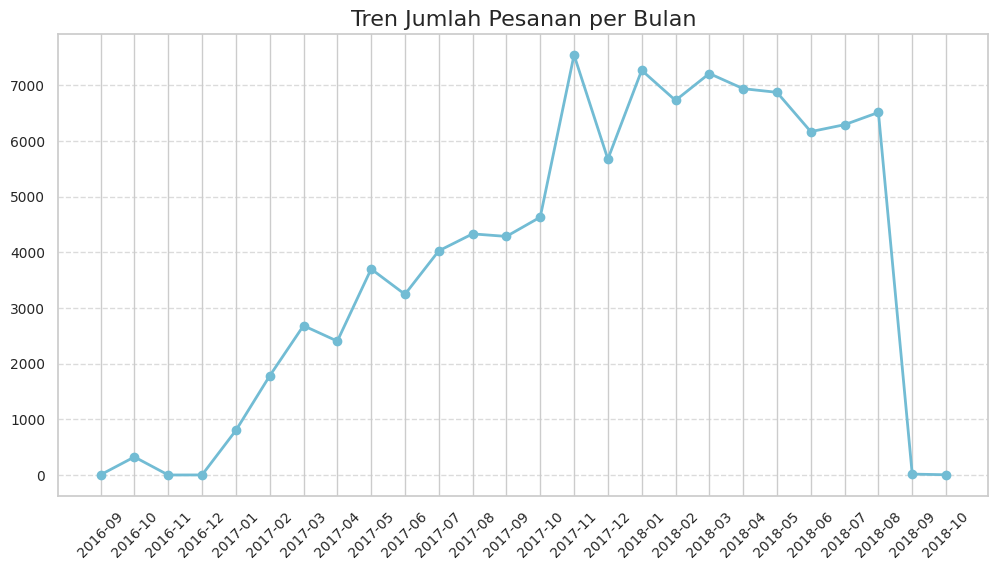

In [43]:
# Menyiapkan data tren bulanan
monthly_orders_df = orders_df.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique"
})
monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')
monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "order_id": "order_count"
}, inplace=True)

# Visualisasi Tren Penjualan
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_orders_df["order_purchase_timestamp"],
    monthly_orders_df["order_count"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Tren Jumlah Pesanan per Bulan", loc="center", fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2381/3040226640.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='payment_type', data=payment_types, palette='Blues_r')


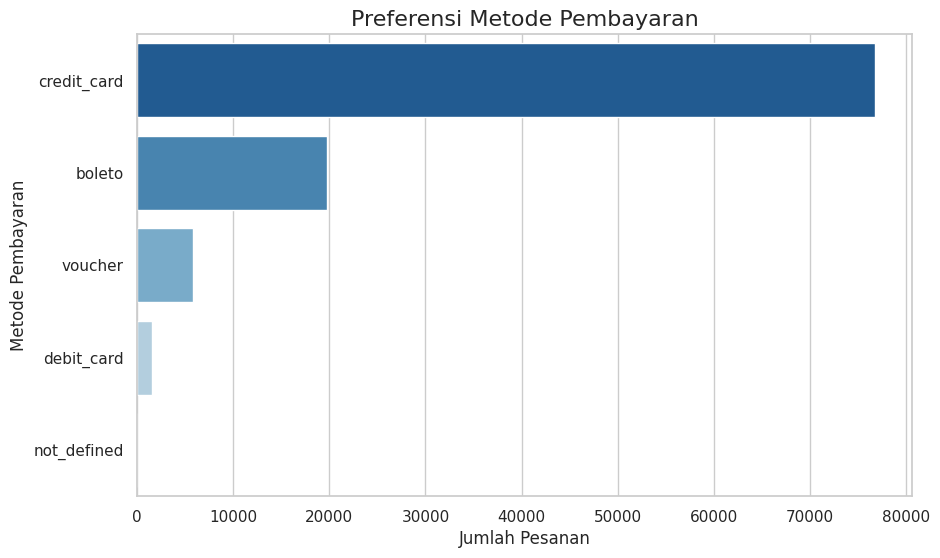

In [44]:
payment_types = order_payments_df['payment_type'].value_counts().reset_index()
payment_types.columns = ['payment_type', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='payment_type', data=payment_types, palette='Blues_r')
plt.title('Preferensi Metode Pembayaran', loc='center', fontsize=16)
plt.xlabel('Jumlah Pesanan')
plt.ylabel('Metode Pembayaran')
plt.show()

**Insight:** (Opsional)
- Penjualan meningkat dengan cepat dan berpuncak pada kuartal ke-4 tahun 2017, dengan tingkat transaksi yang tetap tinggi hingga awal tahun 2018
- Banyak orang lebih memilih menggunakan kartu kredit

## Visualization & Explanatory Analysis

### Pertanyaan 1:

TOP 5 KATEGORI PRODUK BERDASARKAN REVENUE TAHUN 2017
   product_category_name_english  total_revenue  total_orders
7                 bed_bath_table      490596.92          4423
72                 watches_gifts      475610.71          2073
43                 health_beauty      473833.00          3305
66                sports_leisure      435674.14          3540
15         computers_accessories      391786.29          2546
20                    cool_stuff      381414.30          2161
39               furniture_decor      324587.60          3111
70                          toys      299056.71          2404
42                  garden_tools      256949.20          1934
5                           auto      234550.09          1383


/tmp/ipykernel_2381/1144484650.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue, x='total_revenue', y='product_category_name_english', palette='Blues_r')


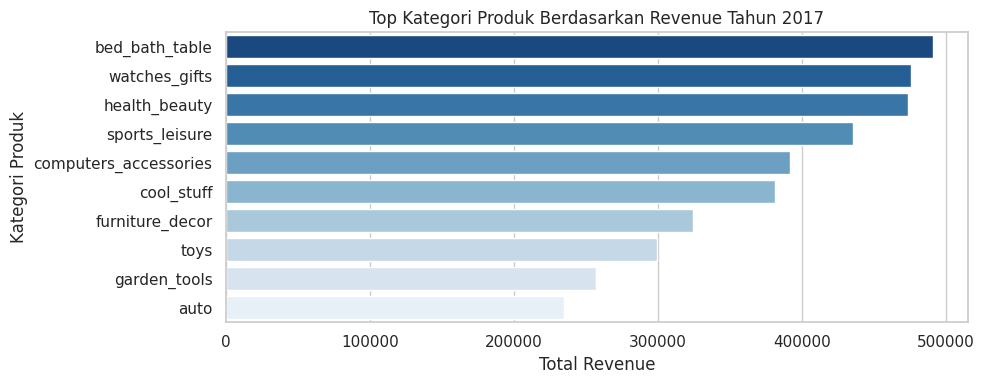

In [45]:
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()

orders_2017 = delivered_orders[delivered_orders['order_purchase_timestamp'].dt.year == 2017]

df_2017 = orders_2017.merge(order_items_df, on='order_id').merge(products_df, on='product_id')

top_products_2017 = df_2017.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique'),
    total_items_sold=('order_item_id', 'count')
).reset_index()

top_revenue = top_products_2017.sort_values(by='total_revenue', ascending=False).head(10)
print("TOP 5 KATEGORI PRODUK BERDASARKAN REVENUE TAHUN 2017")
print(top_revenue[['product_category_name_english', 'total_revenue', 'total_orders']])

# PLOT
plt.figure(figsize=(10, 4))
sns.barplot(data=top_revenue, x='total_revenue', y='product_category_name_english', palette='Blues_r')
plt.title('Top Kategori Produk Berdasarkan Revenue Tahun 2017')
plt.xlabel('Total Revenue')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

ANALISIS METODE PEMBAYARAN 2018
payment_type  total_transactions  avg_transaction_value  total_volume_value  proportion_%
 credit_card               41071             162.568396          6676846.60     75.018266
      boleto                9998             143.256092          1432274.41     18.261854
     voucher                2601              68.294037           177632.79      4.750858
  debit_card                1078             154.194249           166221.40      1.969022


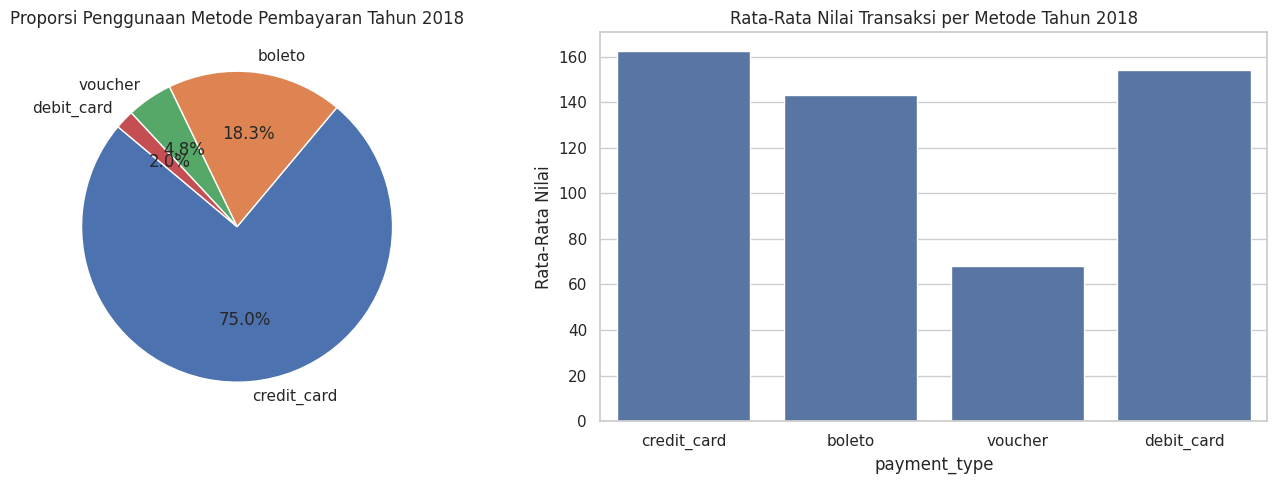

In [46]:
# Filter pesanan 2018
orders_2018 = delivered_orders[delivered_orders['order_purchase_timestamp'].dt.year == 2018]

# Merge orders dan order_payments
df_payments = orders_2018.merge(order_payments_df, on='order_id')

# 3. Agregasi per tipe pembayaran
payment_summary = df_payments.groupby('payment_type').agg(
    total_transactions=('order_id', 'count'),
    avg_transaction_value=('payment_value', 'mean'),
    total_volume_value=('payment_value', 'sum')
).reset_index()

# Hitung persentase proporsi transaksi
payment_summary['proportion_%'] = (payment_summary['total_transactions'] / payment_summary['total_transactions'].sum()) * 100
payment_summary = payment_summary.sort_values(by='total_transactions', ascending=False)

print("ANALISIS METODE PEMBAYARAN 2018")
print(payment_summary.to_string(index=False))

# PLOT
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Proporsi Transaksi
ax[0].pie(payment_summary['total_transactions'], labels=payment_summary['payment_type'], autopct='%1.1f%%', startangle=140)
ax[0].set_title('Proporsi Penggunaan Metode Pembayaran Tahun 2018')

# Chart 2: Rata-Rata Nilai Transaksi per Metode
sns.barplot(data=payment_summary, x='payment_type', y='avg_transaction_value', ax=ax[1])
ax[1].set_title('Rata-Rata Nilai Transaksi per Metode Tahun 2018')
ax[1].set_ylabel('Rata-Rata Nilai')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Kategori produk dengan total revenue tertinggi pada tahun 2017 adalah perlengkapan rumah tangga (bed, bath, table)
- Pelanggan yang menggunakan kartu kredit dan kartu debit cenderung memiliki rata-rata nilai transaksi yang tinggi, dengan kartu kredit mendominasi total volume penjualan secara keseluruhan.

## Analisis Lanjutan (Opsional)

HASIL MANUAL GROUPING
Category :  spend_category
Medium Spender    60485
Low Spender       16452
High Spender      15465
Super Spender      4076
Name: count, dtype: int64
Basket Size :  basket_size
Single Item                 86843
Small Bundle (2-4 items)     9193
Bulk Purchase (>4 items)      442
Name: count, dtype: int64


/tmp/ipykernel_2381/3660327843.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


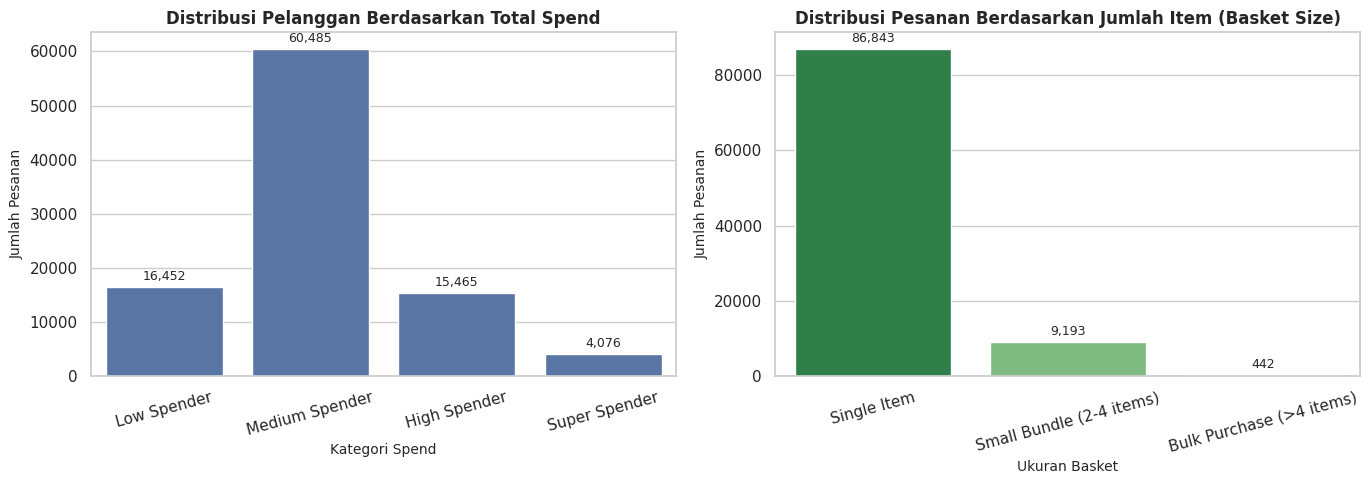

In [47]:
# Filter barang terkirim
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()

# Agregasi total spend dan jumlah item per order_id
order_spend = order_payments_df.groupby('order_id')['payment_value'].sum().reset_index()
order_items_count = order_items_df.groupby('order_id')['order_item_id'].count().reset_index().rename(columns={'order_item_id': 'item_count'})

# Merge ke dataframe orders berdasarkan yang terkirim saja.
df_merged = delivered_orders.merge(order_spend, on='order_id', how='left').merge(order_items_count, on='order_id', how='left')

# isi null dengan 0
df_merged['payment_value'] = df_merged['payment_value'].fillna(0)
df_merged['item_count'] = df_merged['item_count'].fillna(0)

# Pengelompokkan berdasarkan total pengeluaran per pembelian
def classify_spending(value):
    if value < 50:
        return 'Low Spender'
    elif 50 <= value <= 200:
        return 'Medium Spender'
    elif 200 < value <= 500:
        return 'High Spender'
    else:
        return 'Super Spender'

# Pengelompokkan berdasarkan total item per pembelian
def classify_basket_size(items):
    if items == 1:
        return 'Single Item'
    elif 2 <= items <= 4:
        return 'Small Bundle (2-4 items)'
    else:
        return 'Bulk Purchase (>4 items)'


df_merged['spend_category'] = df_merged['payment_value'].apply(classify_spending)
df_merged['basket_size'] = df_merged['item_count'].apply(classify_basket_size)


print("HASIL MANUAL GROUPING")
print("Category : ",df_merged['spend_category'].value_counts())
print("Basket Size : ",df_merged['basket_size'].value_counts())

# VISUALISASI
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualisasi Spend Category
order_spend = ['Low Spender', 'Medium Spender', 'High Spender', 'Super Spender']
sns.countplot(
    data=df_merged,
    x='spend_category',
    order=order_spend,
    ax=axes[0]
)
axes[0].set_title('Distribusi Pelanggan Berdasarkan Total Spend', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori Spend', fontsize=10)
axes[0].set_ylabel('Jumlah Pesanan', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# Menambahkan label angka di atas bar (Axes 1)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height):,}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                         textcoords='offset points')

# Visualisasi Basket Size
order_basket = ['Single Item', 'Small Bundle (2-4 items)', 'Bulk Purchase (>4 items)']
sns.countplot(
    data=df_merged,
    x='basket_size',
    order=order_basket,
    palette='Greens_r',
    ax=axes[1]
)
axes[1].set_title('Distribusi Pesanan Berdasarkan Jumlah Item (Basket Size)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ukuran Basket', fontsize=10)
axes[1].set_ylabel('Jumlah Pesanan', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

# Menambahkan label angka di atas bar (Axes 2)
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{int(height):,}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Medium Spender menjadi mayoritas transaksi. Ini menunjukkan sweet spot belanja pembeli Olist berada pada rentang pertengahan (sekitar R$ 50–200).
- Sebanyak 86.843 transaksi hanya berisi 1 item barang. Pembeli cenderung belanja satu barang, bukan memborong berbagai macam produk sekaligus.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Produk paling mencetak revenue adalah bed_bath_table sebesar 490.596,92, watches_gifts dan health_beauty. Produk yang paling banyak pesanan juga bed_bath_table yaitu 4.423 pesanan, diikuti oleh sports_leisure (3.540 pesanan) dan health_beauty (3.305 pesanan). Kategori watches_gifts mencetak revenue yang sangat tinggi meskipun jumlah pesanan relatif sedang (2.073 pesanan), mengindikasikan Average Order Value (AOV) per produk yang tinggi pada kategori ini.
- **Conclusion pertanyaan 2:** Metode credit_card sangat mendominasi transaksi pada tahun 2018 dan rata-rata nilai transaksi tertinggi sebesar 162,57. boleto menjadi metode pembayaran populer kedua dengan rata-rata nilai transaksi 143,26.

**Rekomendasi Action Item:**
- Prioritaskan ketersediaan stok pasokan untuk kategori bed_bath_table, health_beauty, dan sports_leisure, terutama pada periode puncak penjualan agar tidak terjadi kehabisan stok. Buat strategi bundling atau penawaran produk pelengkap antara kategori bernilai tinggi seperti watches_gifts dengan produk populer dari health_beauty untuk makin menaikkan total keranjang belanja.
- Karena credit_card menyumbang 75% transaksi, jalin kerja sama dengan penyedia kartu kredit/bank untuk memberikan program cicilan 0% atau cashback khusus guna mempertahankan serta mendorong nominal transaksi yang lebih besar.